# XStream_utils Example

This notebook demonstrates the two main tools in `XStream_utils`:
- `plot_corner` — weighted corner plot using the H_mean statistic
- `h_mean_quantile` — H_mean-consistent credible intervals

Chains loaded here come from X-Stream. Each chain contains `points_good` (parameter samples) and `prob_values_of_samples` (normalized significance weights).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from XStream_utils import plot_corner, h_mean_quantile

## Load chains

In [2]:
chains_inner = np.load('chains_inner.npy', allow_pickle=True).item()
chains_outer = np.load('chains_outer.npy', allow_pickle=True).item()
 

print("inner points_good shape :", chains_inner['points_good'].shape)
print("outer points_good shape :", chains_outer['points_good'].shape)
 

inner points_good shape : (59062, 10)
outer points_good shape : (15818, 10)


## Extract NFW halo parameters

The NFW halo parameters live at columns 5–8
 

In [3]:
# Parameter indices
LOG10M_IDX, RS_IDX, GAMMA_IDX, BETA_IDX = 5, 6, 7, 8

param_labels = [
    r'$\log_{10}(M/M_\odot)$',
    r'$r_s\ [\mathrm{kpc}]$',
    r'$\gamma$',
    r'$\beta$',
]
true_params = [13.0, 22.0, 1.0, 3.0]
param_cols   = [LOG10M_IDX, RS_IDX, GAMMA_IDX, BETA_IDX]

pts_inner = chains_inner['points_good'][:, param_cols]
w_inner   = chains_inner['prob_values_of_samples']

pts_outer = chains_outer['points_good'][:, param_cols]
w_outer   = chains_outer['prob_values_of_samples']


## Corner plot — Inner stream

`plot_corner` displays the H_mean (mean weight per bin) in both the 2-D heatmap panels and the 1-D diagonal histograms. Black lines mark the ground-truth parameter values.

In [4]:
help(plot_corner)

Help on function plot_corner in module XStream_utils.plotcontours:

plot_corner(
    points_good,
    prob_values_of_samples,
    true_params,
    prior_keys_latex,
    n_bins=15,
    show_contours=True,
    global_norm=False,
    contour_levels=(0.68, 0.95),
    smooth_contours=True,
    smooth_sigma=1.0,
    contour_on_mean=True,
    hist1d_on_mean=True,
    cmap='Purples',
    contour_colors='k',
    contour_linestyles=('--', '-'),
    density=True,
    hist1d_histtype='bar',
    hist1d_color='mediumpurple',
    hist1d_density=True,
    axis_fraction=1.0,
    figsize=(22, 22),
    savefig=None,
    fig=None,
    subplot_spec=None,
    axes_dict=None
)
    Custom weighted corner plot — no resampling, no `corner` package.
    We take the parameter samples and their normalised significance weights (from Lambda(sigma) calculation)
    and plot the mean weight per bin in the 2-D panels, which visually corresponds to the heatmap colour. The contours can be drawn
    from either the mean w

/Users/JacobNibauer/Desktop/projects/local/XStream_utils/XStream_utils/plotcontours.py:364: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax.contour(


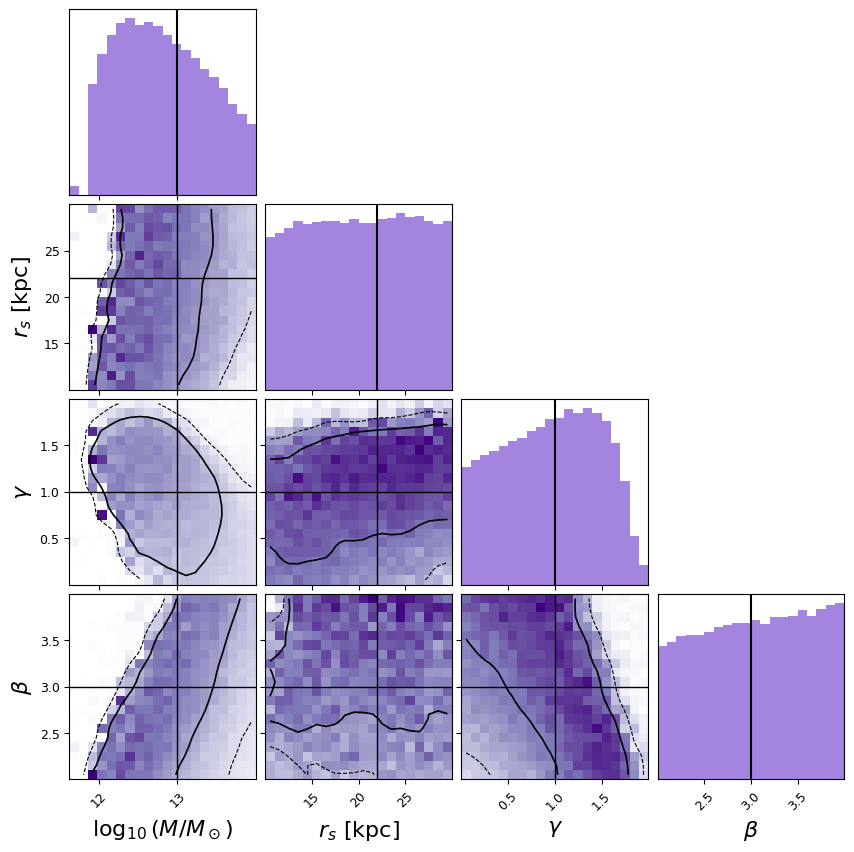

In [5]:
fig_inner, axes_inner = plot_corner(
    pts_inner,
    w_inner,
    true_params=true_params,
    prior_keys_latex=param_labels,
    n_bins=20,
    contour_levels=(0.68, 0.95),
    cmap='Purples',
    figsize=(10, 10),
)
plt.show()

## Corner plot — Outer stream

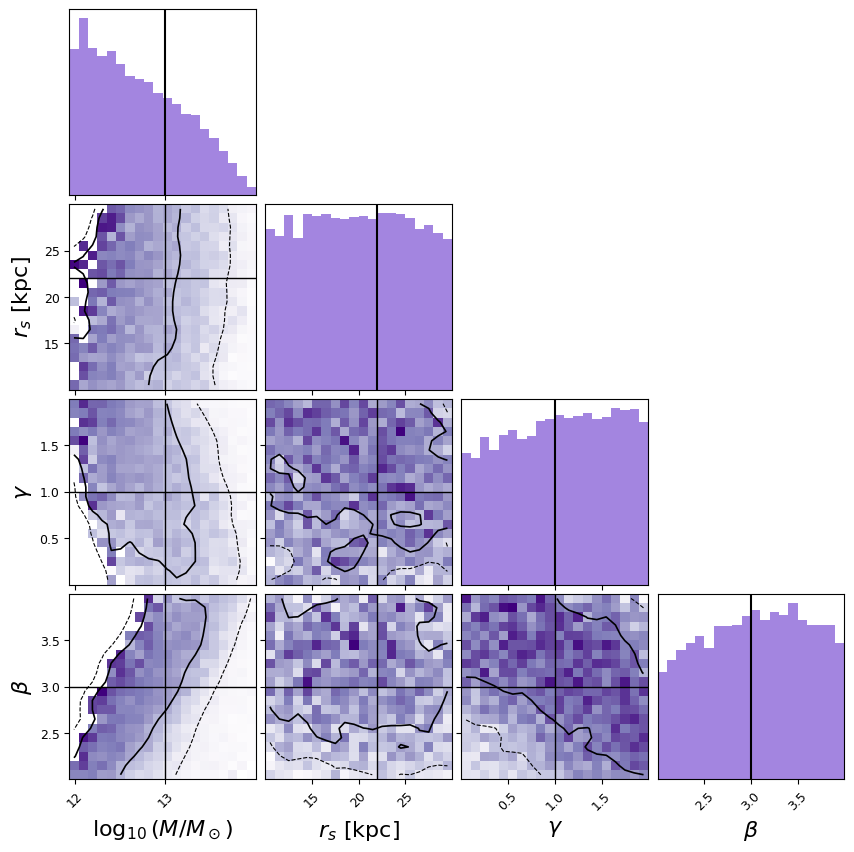

In [6]:
fig_outer, axes_outer = plot_corner(
    pts_outer,
    w_outer,
    true_params=true_params,
    prior_keys_latex=param_labels,
    n_bins=20,
    contour_levels=(0.68, 0.95),
    cmap='Purples',
    figsize=(10, 10),
)
plt.show()

## Custom plotting: turn off the density, control the contour style


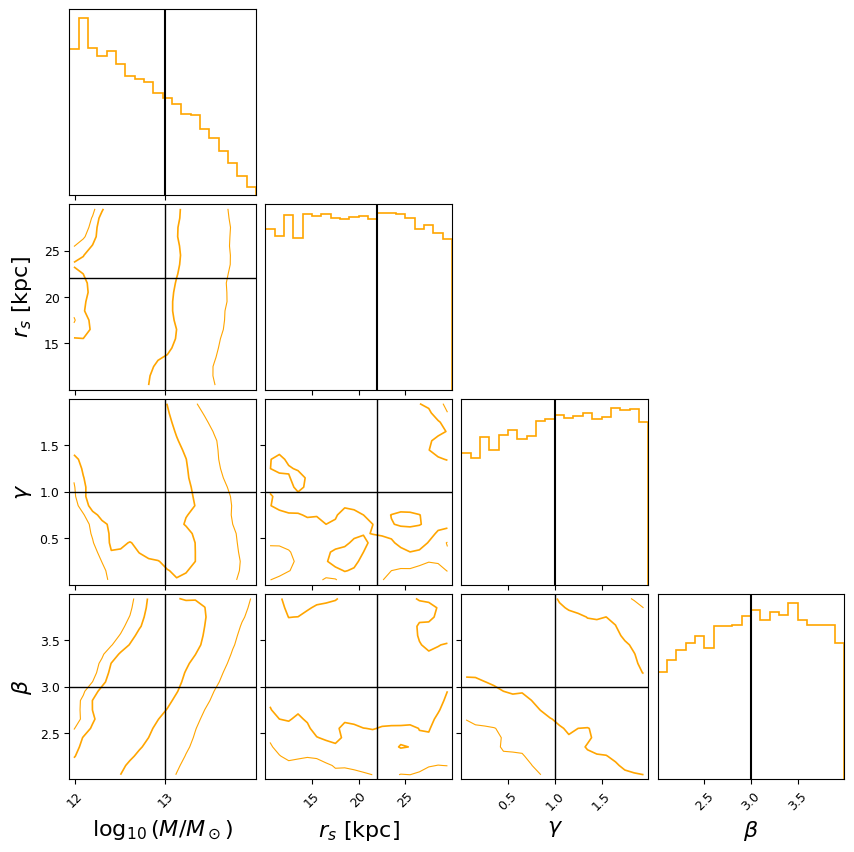

In [7]:
fig_outer, axes_outer = plot_corner(
    pts_outer,
    w_outer,
    true_params=true_params,
    prior_keys_latex=param_labels,
    n_bins=20,
    contour_levels=(0.68, 0.95),
    cmap='Purples',
    figsize=(10, 10),
    density=False,
    contour_colors='orange',
    contour_linestyles=('-','-'),
    hist1d_histtype='step',
    hist1d_color='orange'
)


plt.show()

## Plotting two distributions together

/Users/JacobNibauer/Desktop/projects/local/XStream_utils/XStream_utils/plotcontours.py:364: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax.contour(


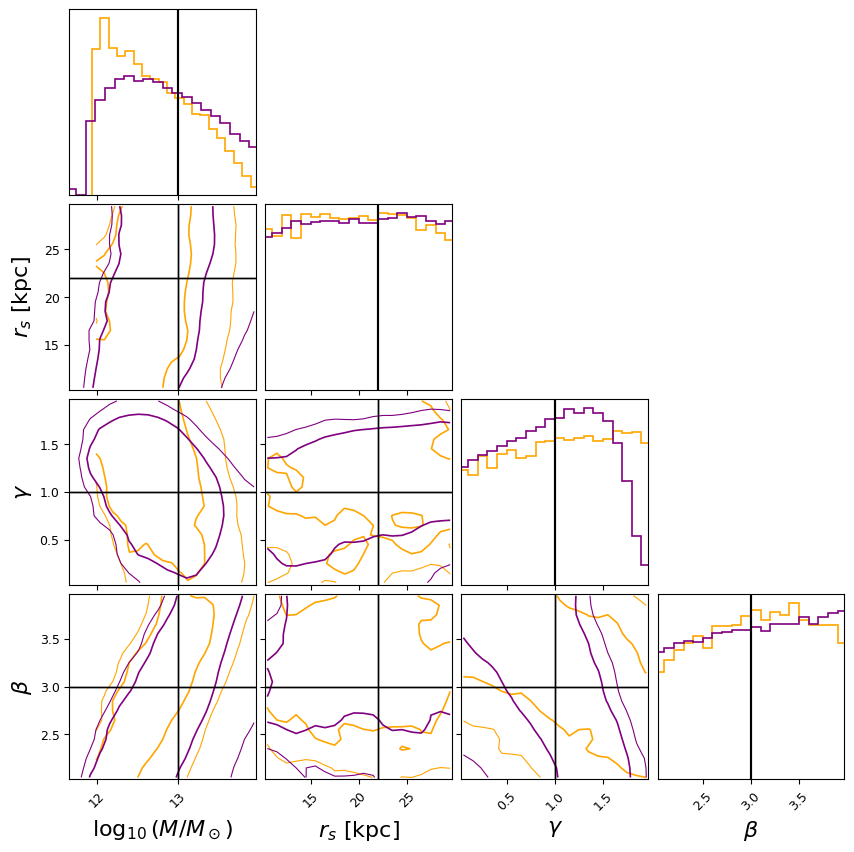

In [14]:
fig, axes = plot_corner(                                                                                                                       
      pts_outer, w_outer,                                                                                                                          
      true_params=true_params,                                                                                                                     
      prior_keys_latex=param_labels,                                                                                                               
      n_bins=20,                                                                                                                                   
      contour_levels=(0.68, 0.95),                                                                                                                 
      figsize=(10, 10),                                                                                                                            
      density=False,                                                                                                                             
      contour_colors='orange',                                                                                                                     
      contour_linestyles=('-', '-'),                                                                                                               
      hist1d_histtype='step',
      hist1d_color='orange', 
      axis_fraction=.97      # <-- depending on bin size it is useful to zoom in a bit so that contours do not abruptly end at the plot edges
                             #     this happens because we draw contours on binned data.        
                             #     default value is 1.0 (show everything)                                                                                       
  )                                                                                                                                                
   
fig, axes = plot_corner(                                                                                                                         
      pts_inner, w_inner,                                                                                                                        
      true_params=true_params,                                                                                                                     
      prior_keys_latex=param_labels,                                                                                                               
      n_bins=20,
      contour_levels=(0.68, 0.95),                                                                                                                 
      contour_colors='purple',  
      density=False,
      contour_linestyles=('-', '-'),   
      hist1d_histtype='step',
      hist1d_color='purple',                                                                                                                          
      axes_dict=axes,   # <-- overlay onto the first plot   
      axis_fraction=.97                                                                                                    
  )                                                                                                                                                
                                                                                                                                                   
plt.show()        

## H_mean histogram & quantiles for log₁₀(M)

Here we manually compute the H_mean 1-D histogram for the log-mass parameter and overlay the 16th / 50th / 84th percentile credible intervals derived with `h_mean_quantile`.

The H_mean histogram divides each bin's total weight by the number of samples in that bin, removing the artefact of sampling density — it is what `plot_corner`'s diagonal panels show.

In [15]:
n_bins  = 20
values  = pts_inner[:, 0]          # log10(M) column
weights = w_inner

# H_mean histogram
H_sum,   edges = np.histogram(values, bins=n_bins, weights=weights)
H_count, _     = np.histogram(values, bins=n_bins)
H_mean = np.where(H_count > 0, H_sum / H_count, 0.0)
centers = 0.5 * (edges[:-1] + edges[1:])

# H_mean quantiles
q16, q50, q84 = h_mean_quantile(values, weights, [0.16, 0.50, 0.84], n_bins=n_bins)
print(f'16th pct : {q16:.3f}')
print(f'median   : {q50:.3f}')
print(f'84th pct : {q84:.3f}')
print(f'truth    : {true_params[0]:.3f}')

16th pct : 12.140
median   : 12.720
84th pct : 13.420
truth    : 13.000


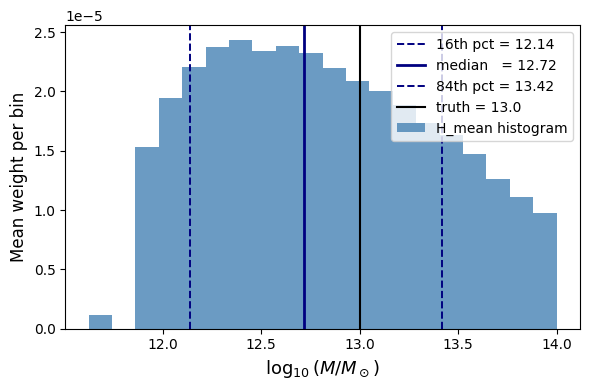

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(centers, H_mean, width=np.diff(edges),
       color='steelblue', alpha=0.8, linewidth=0, label='H_mean histogram')

ax.axvline(q16, color='navy', lw=1.4, ls='--', label=f'16th pct = {q16:.2f}')
ax.axvline(q50, color='navy', lw=2.0, ls='-',  label=f'median   = {q50:.2f}')
ax.axvline(q84, color='navy', lw=1.4, ls='--', label=f'84th pct = {q84:.2f}')
ax.axvline(true_params[0], color='k', lw=1.5, ls='-', label=f'truth = {true_params[0]:.1f}')

ax.set_xlabel(param_labels[0], fontsize=13)
ax.set_ylabel('Mean weight per bin', fontsize=12)
#ax.set_title('Inner stream — H_mean histogram of log₁₀(M)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()